📊 in window] Overview


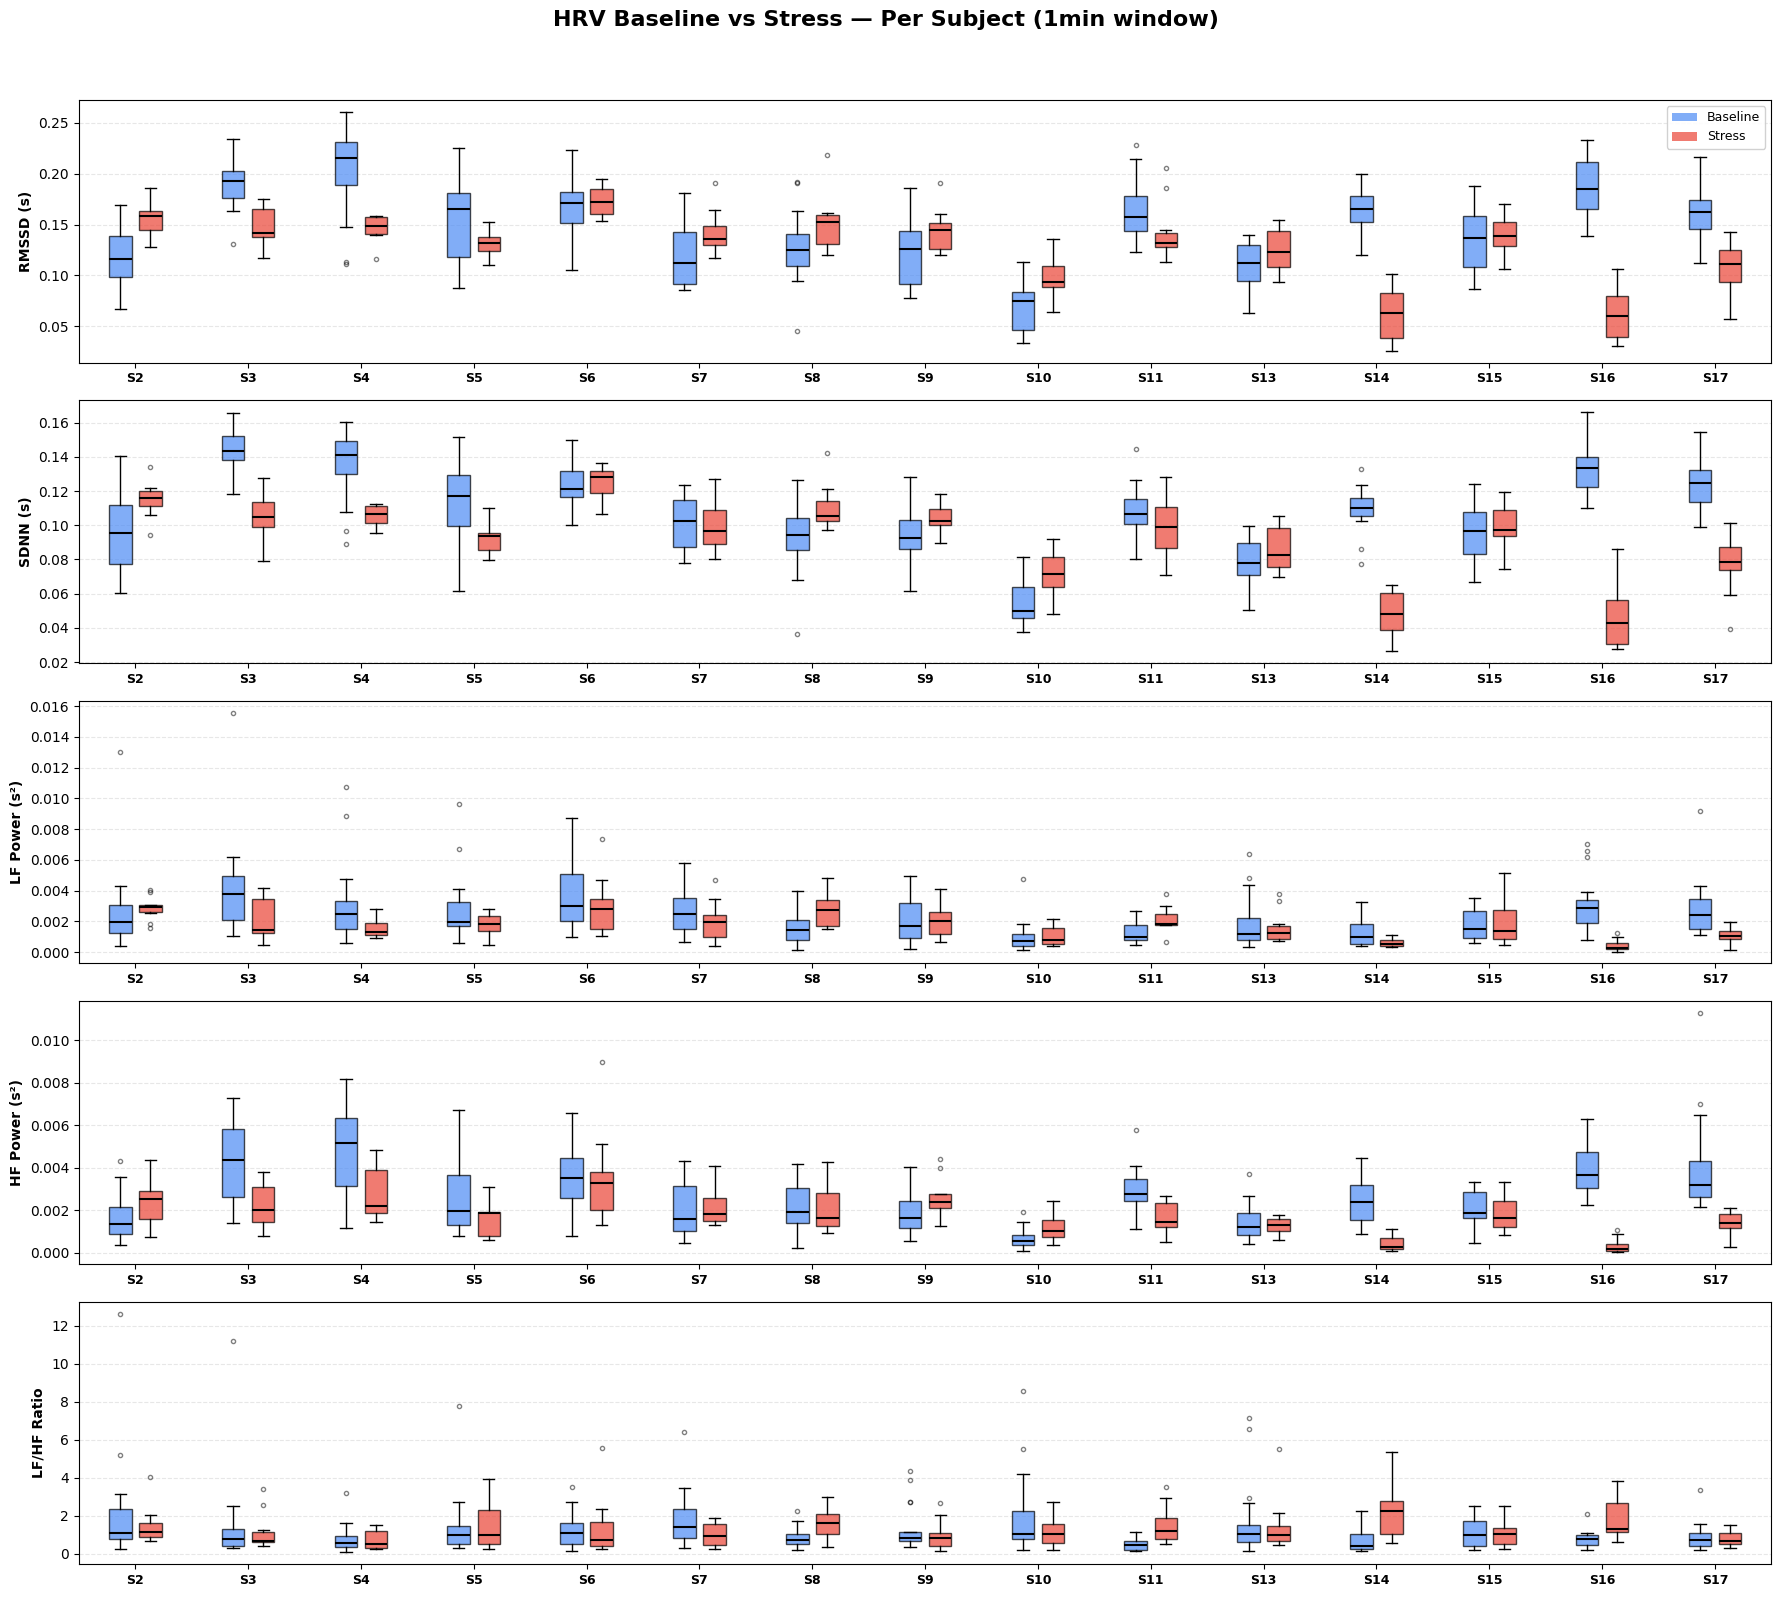


📊 in window] Overview


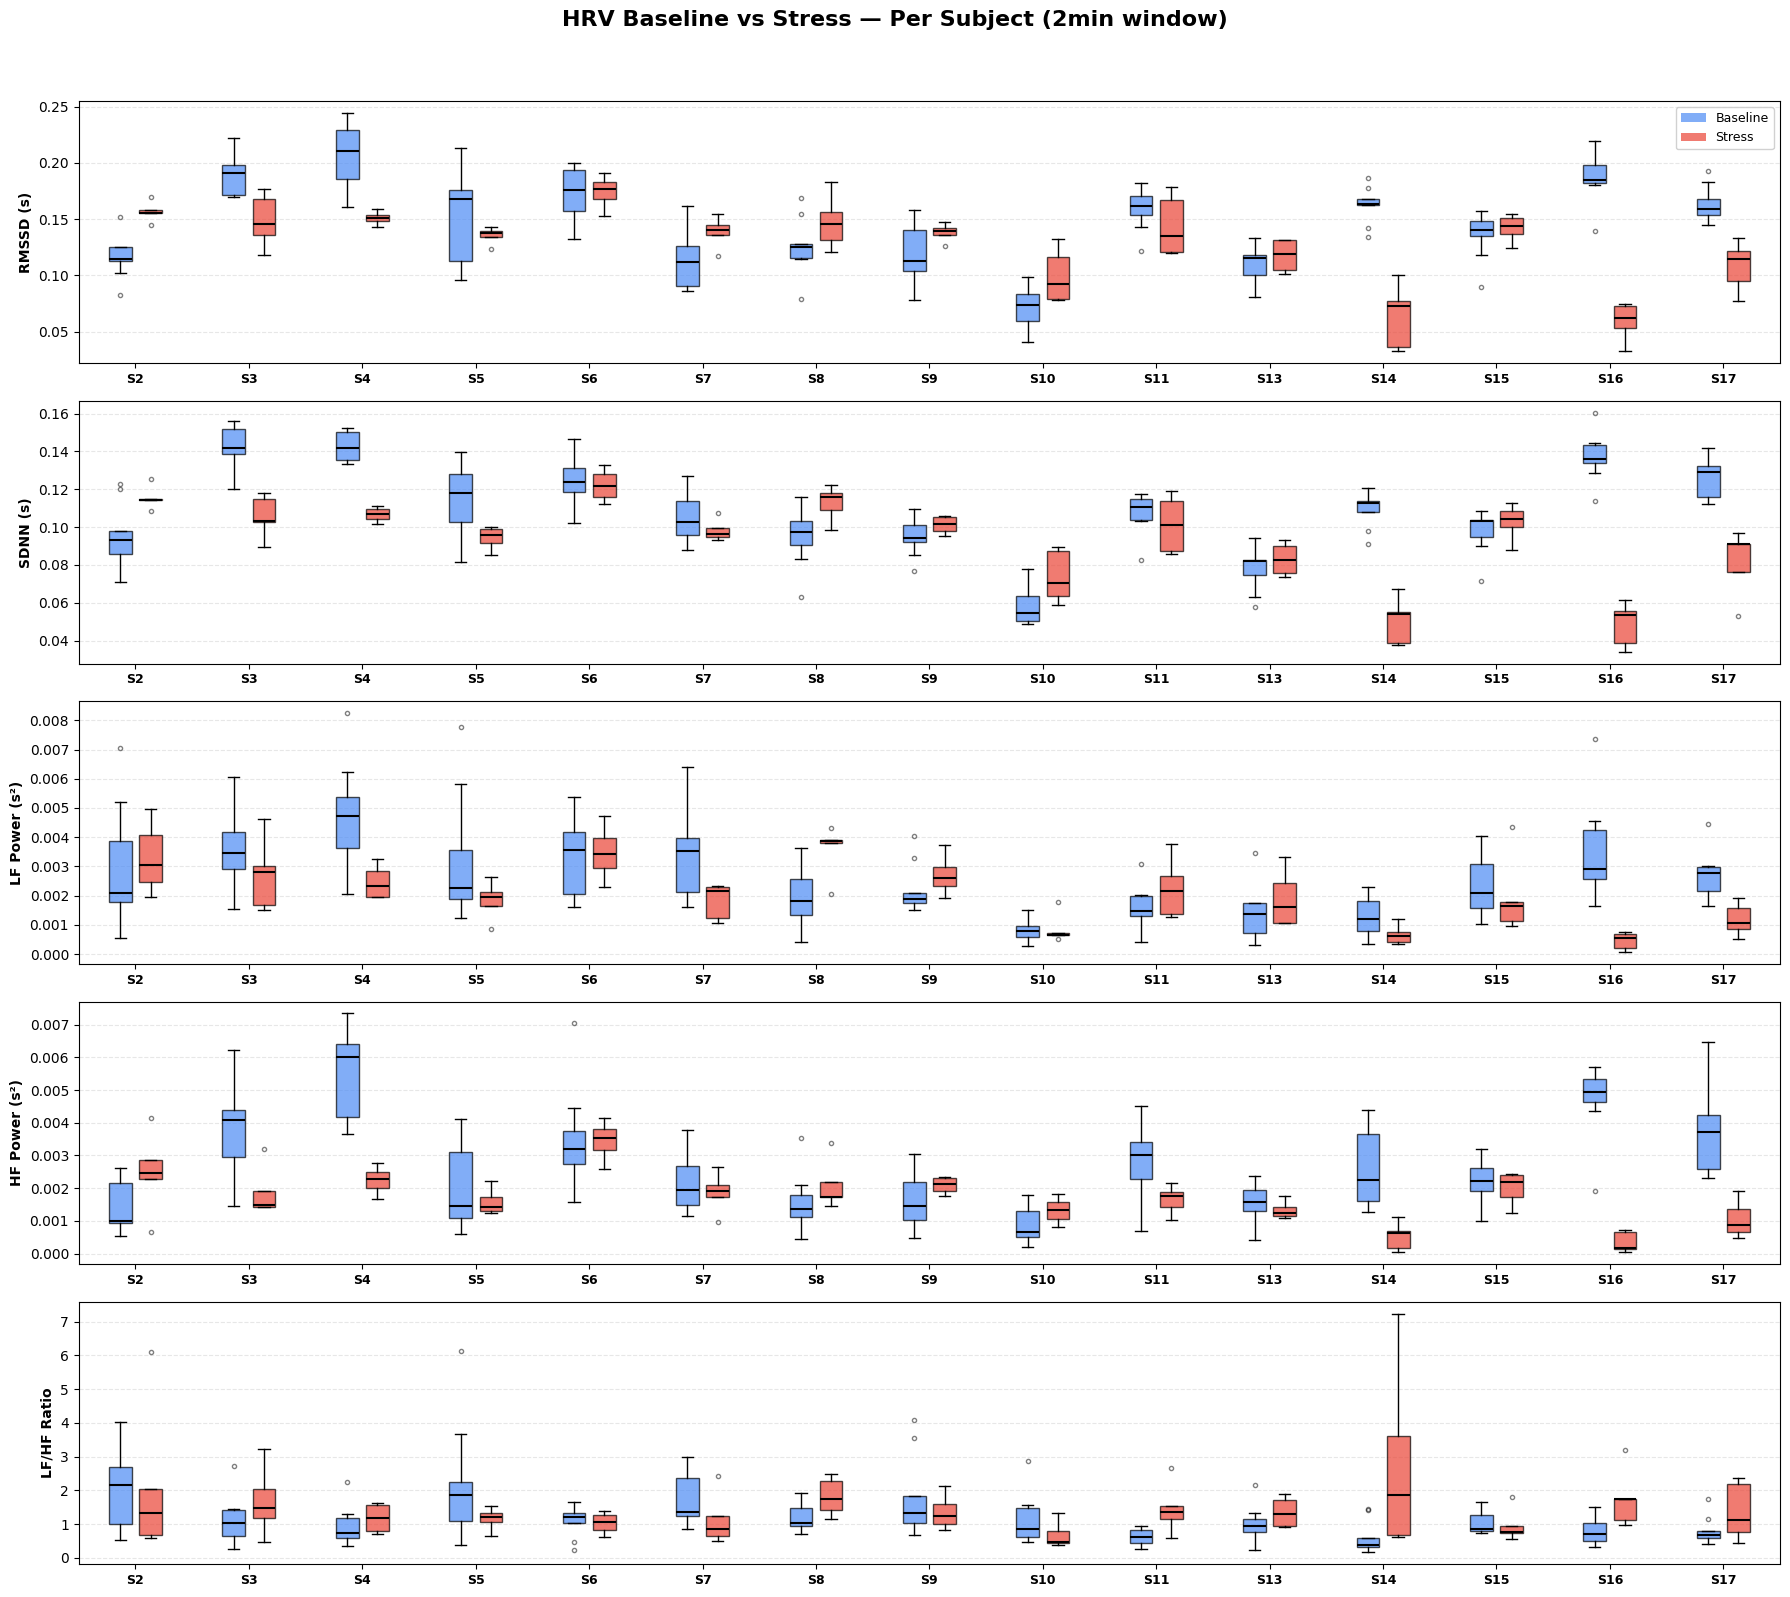


📊 in window] Per-Subject Detail


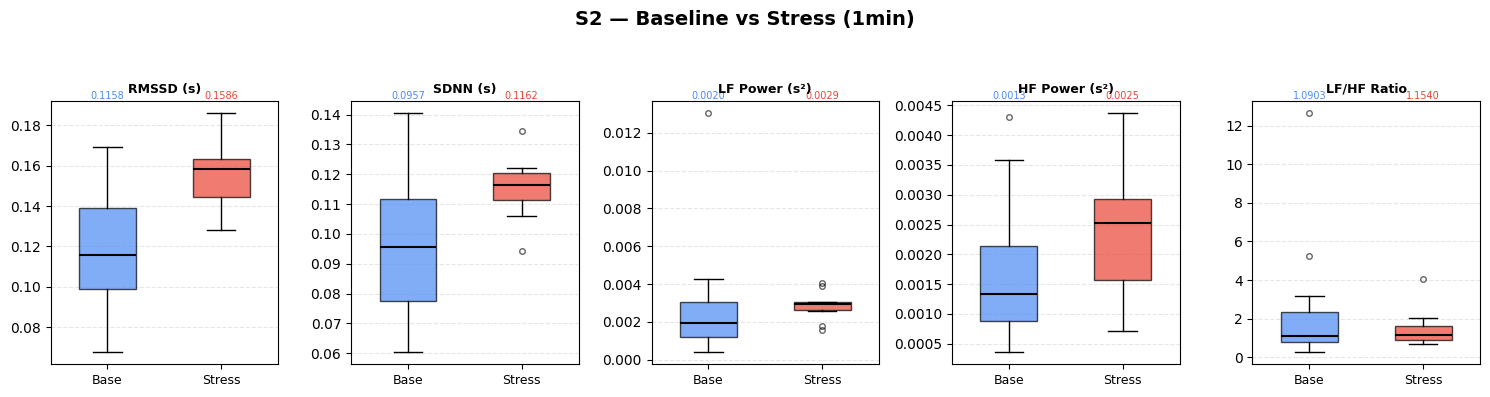

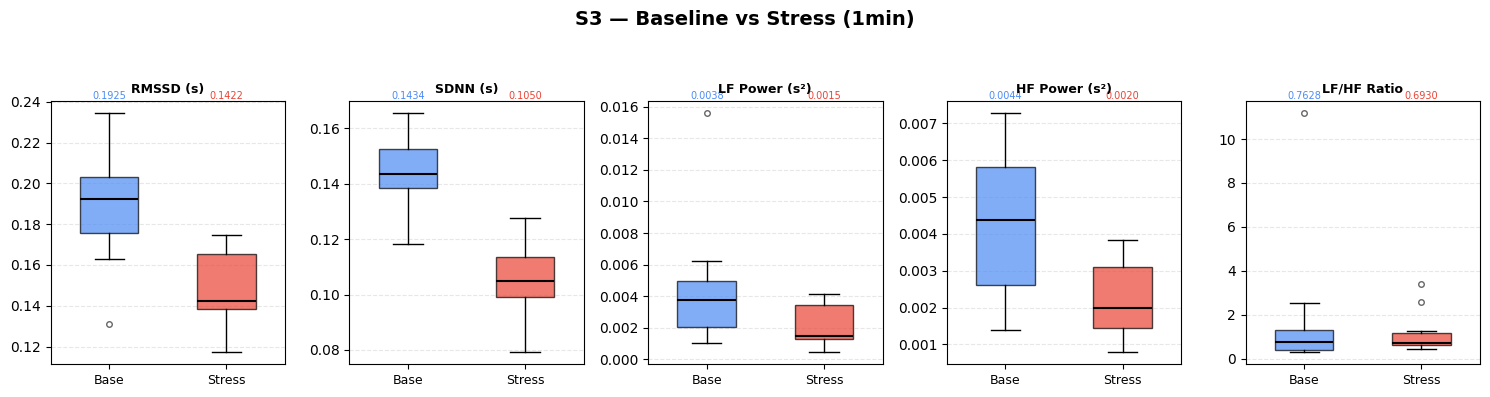

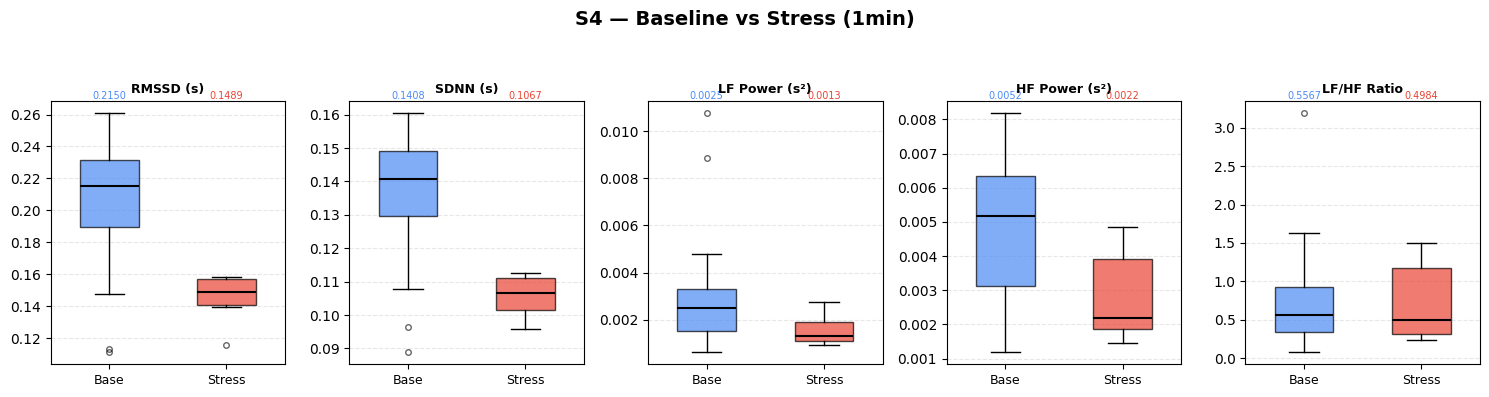

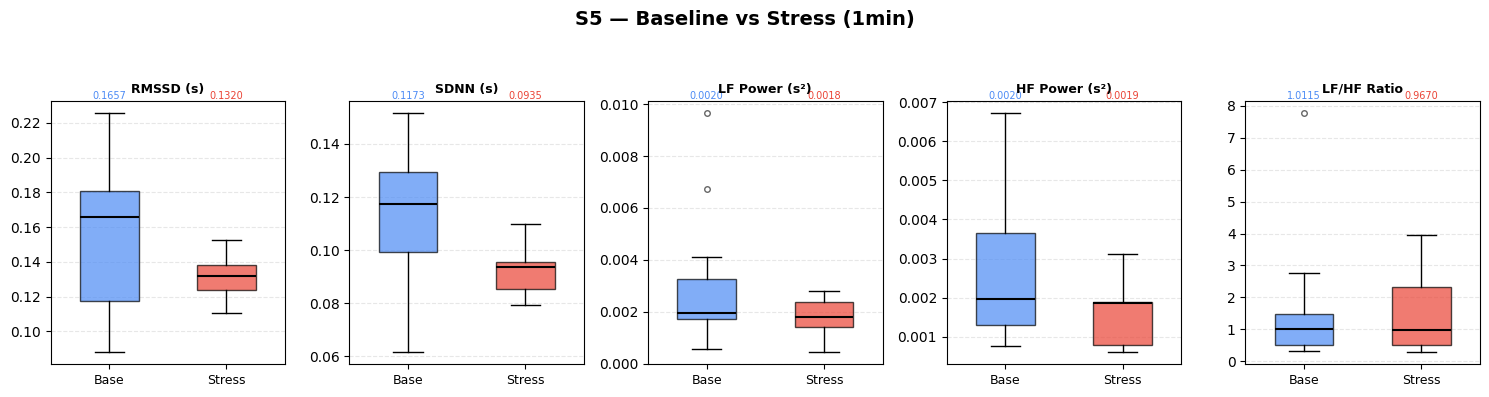

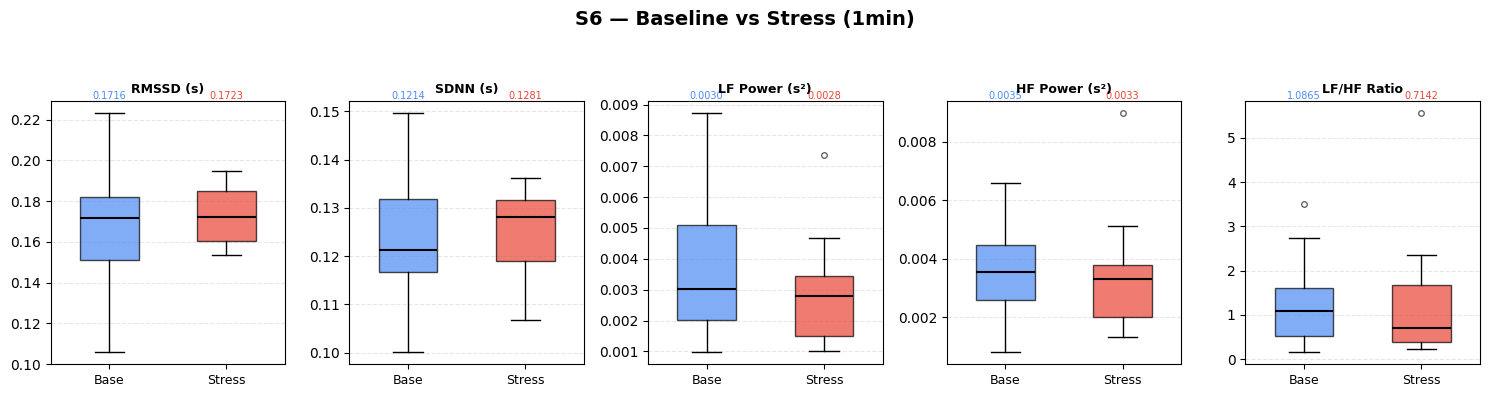

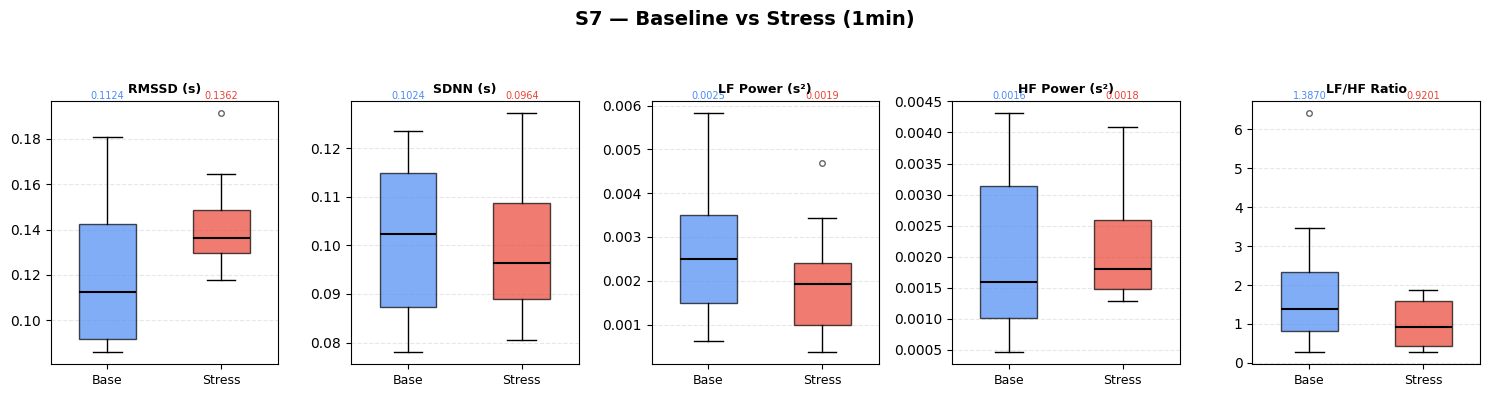

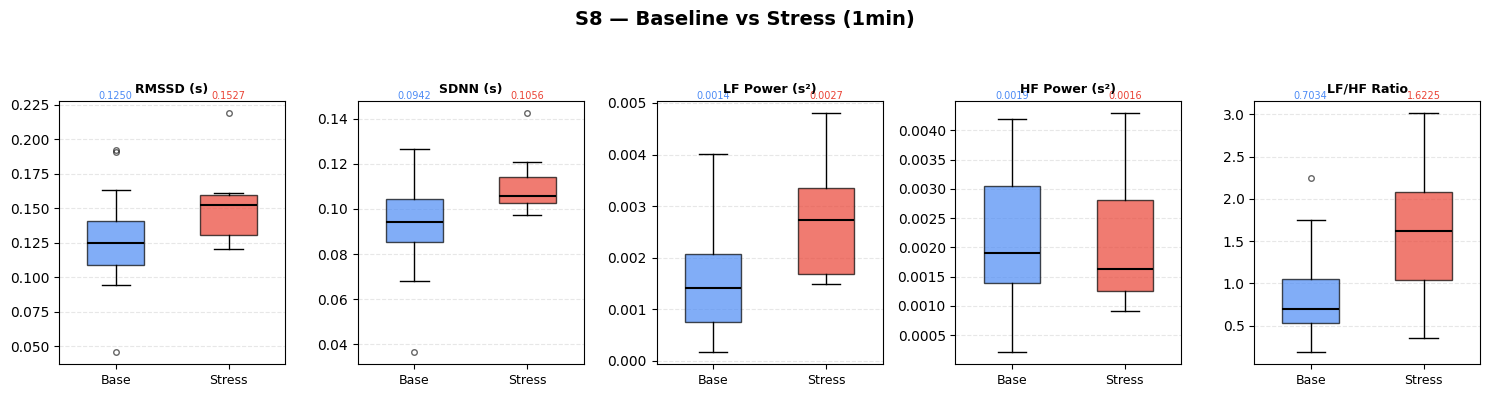

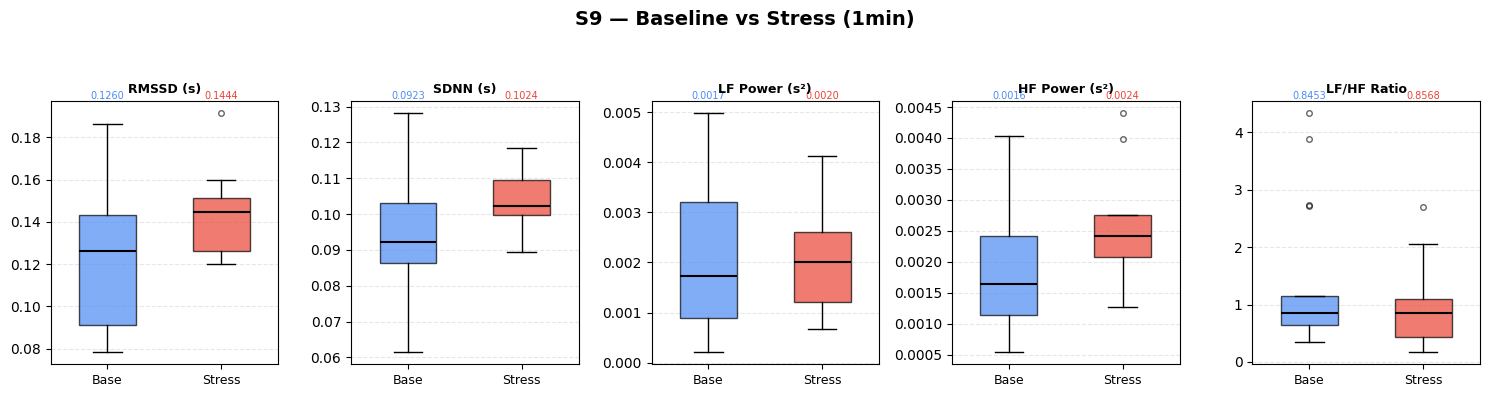

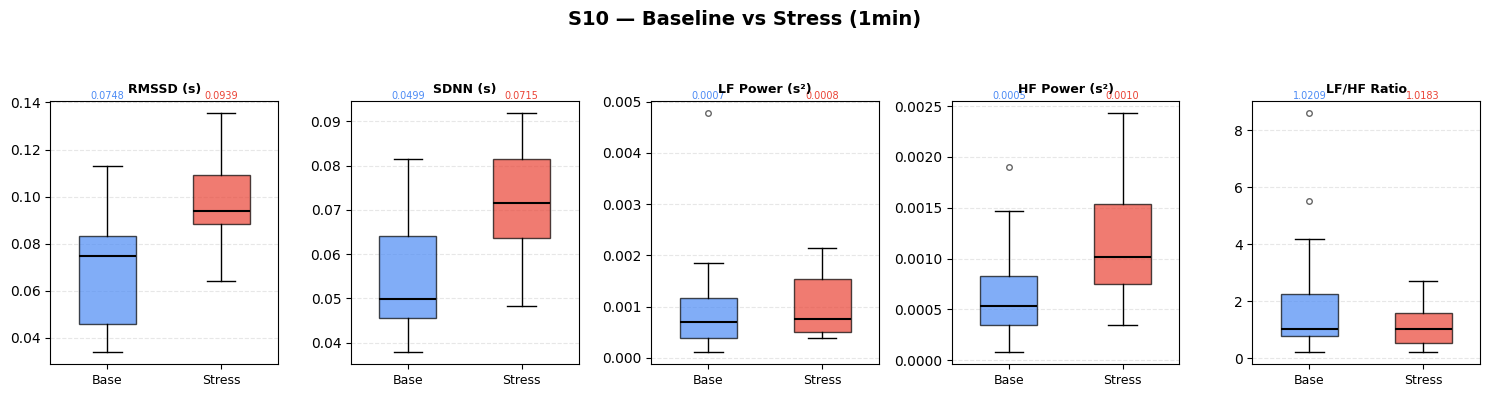

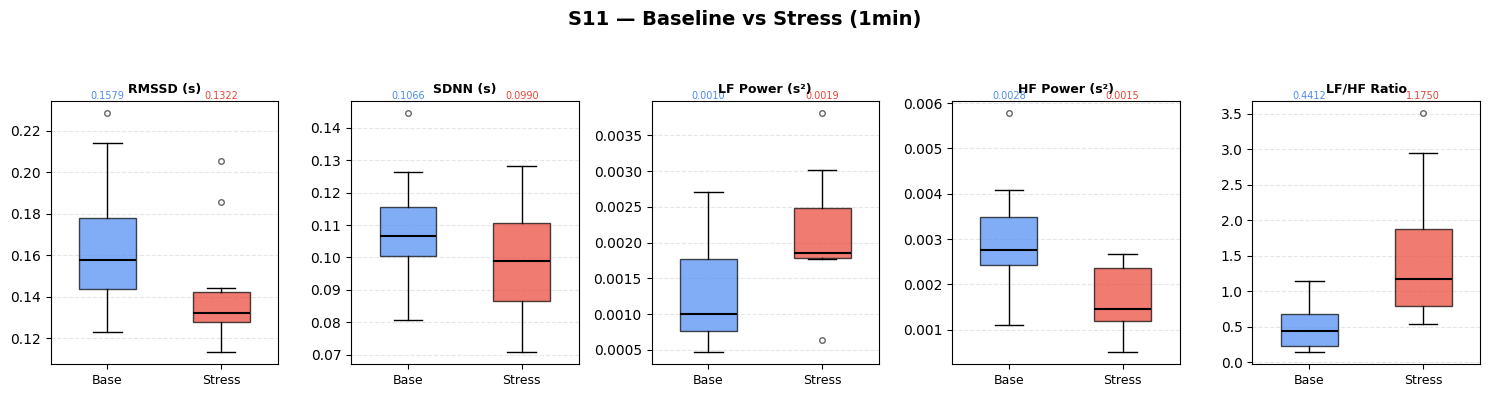

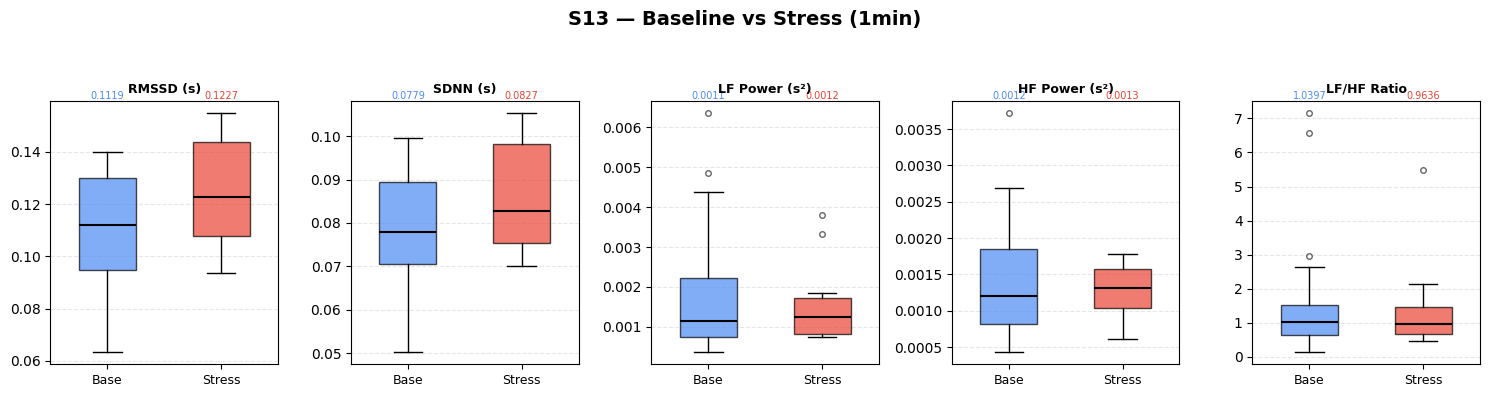

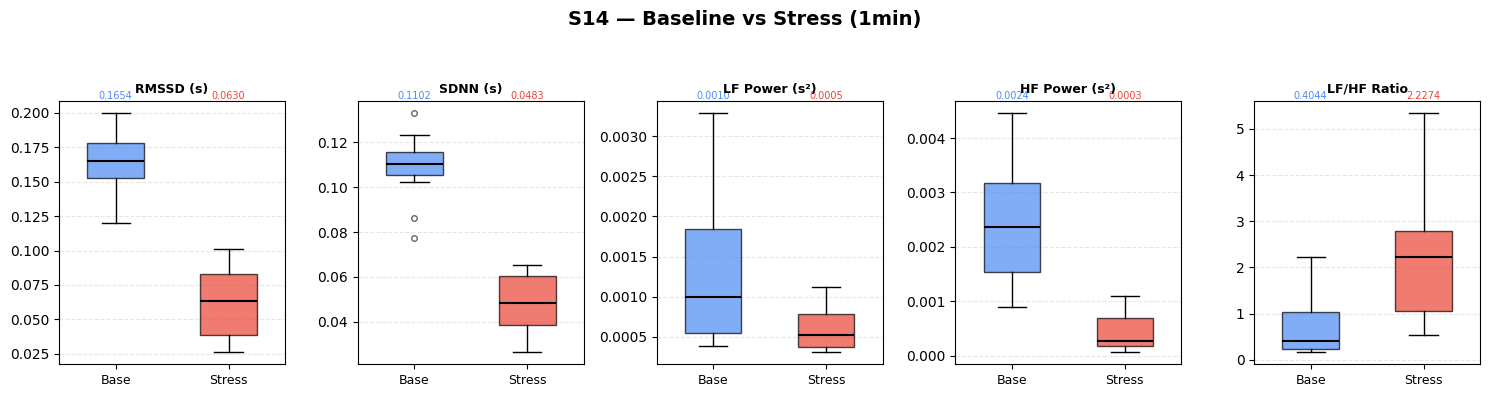

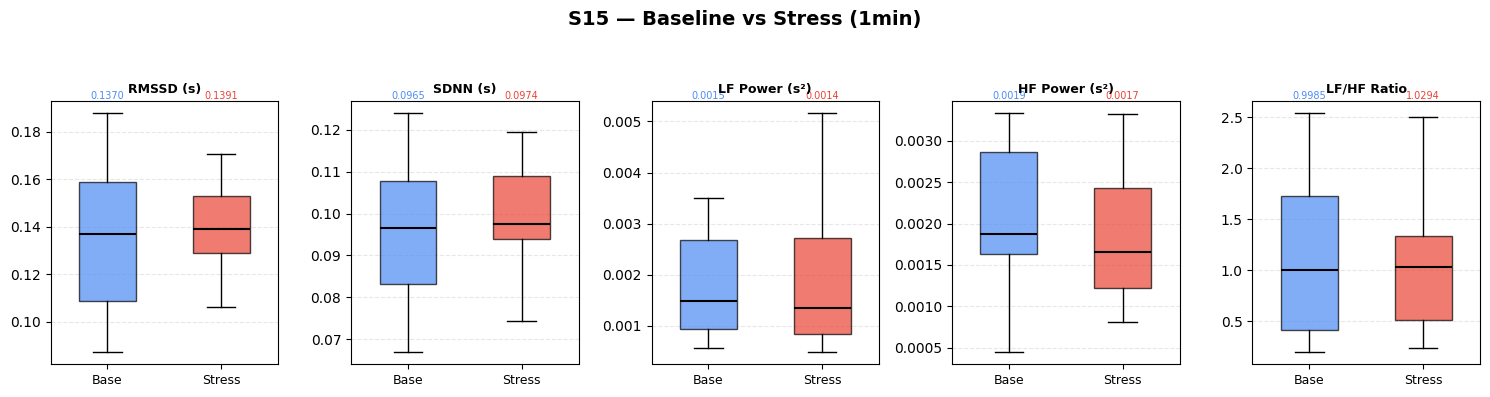

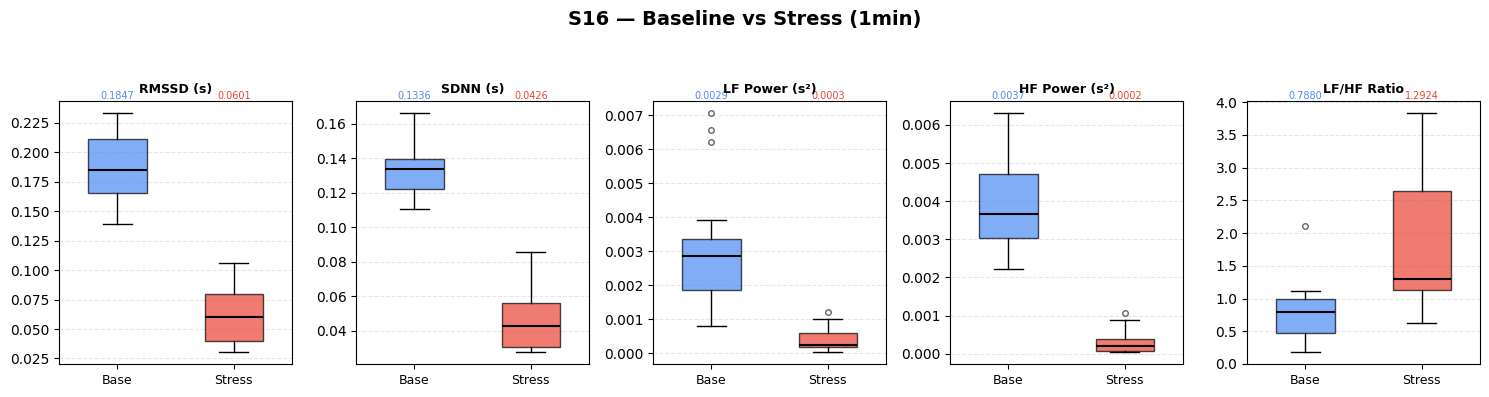

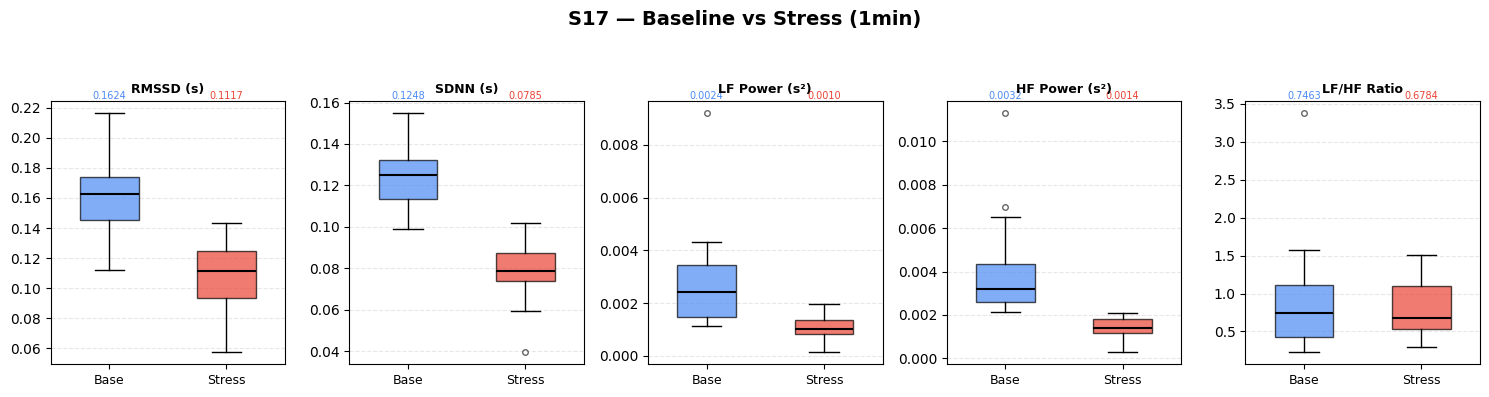


📊 in window] Per-Subject Detail


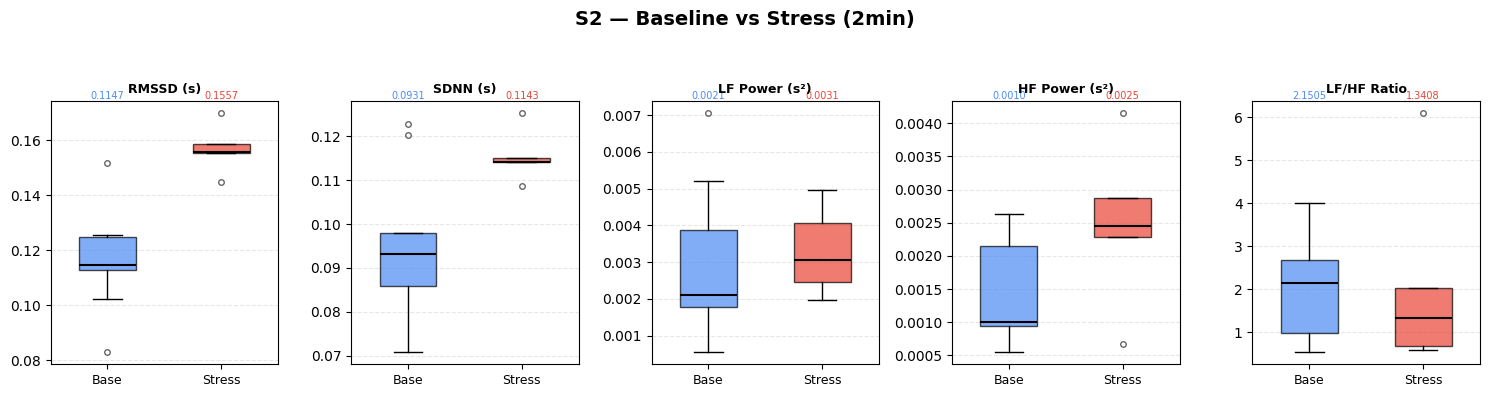

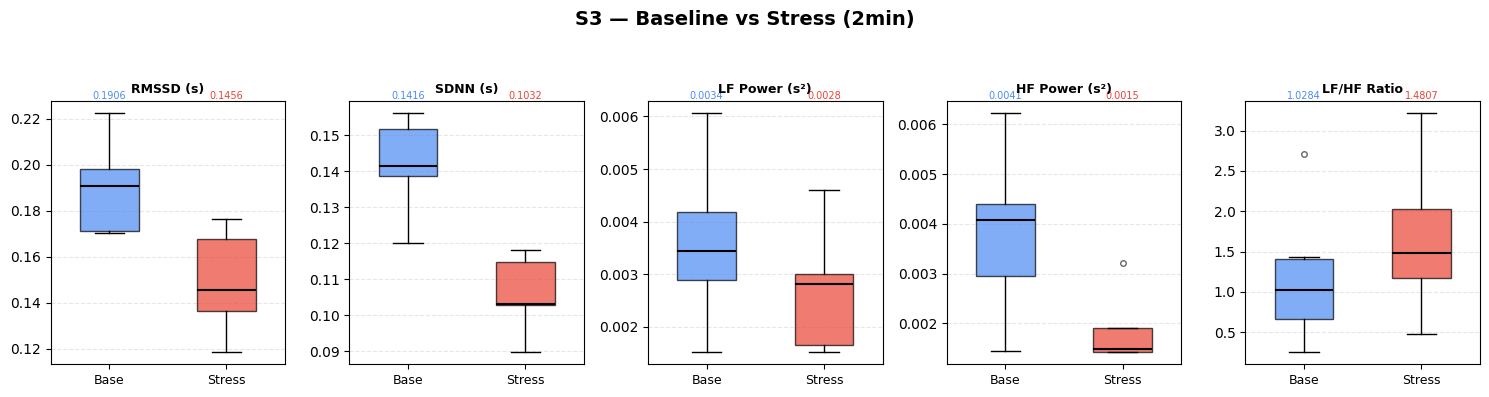

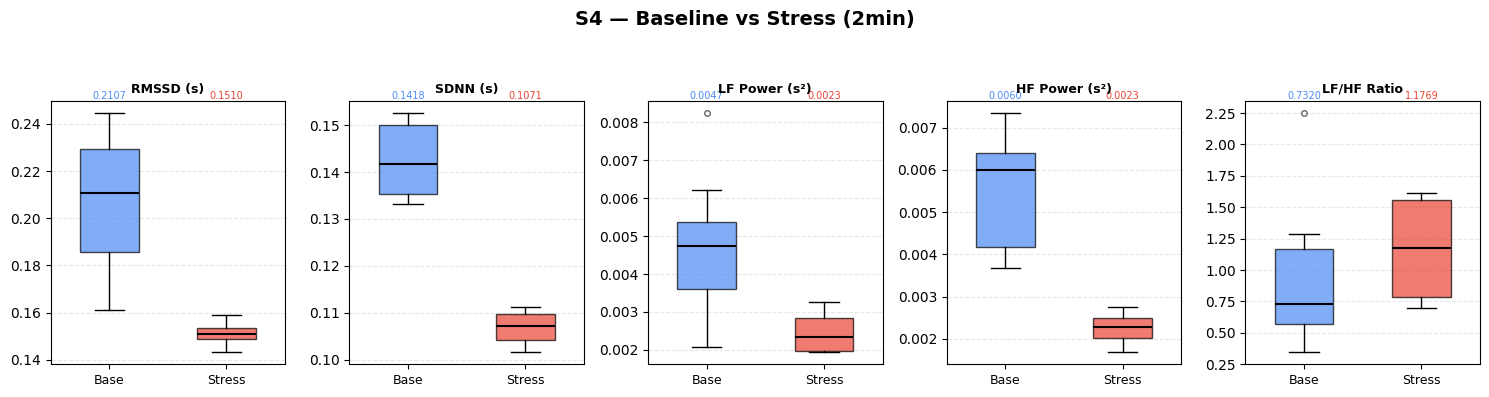

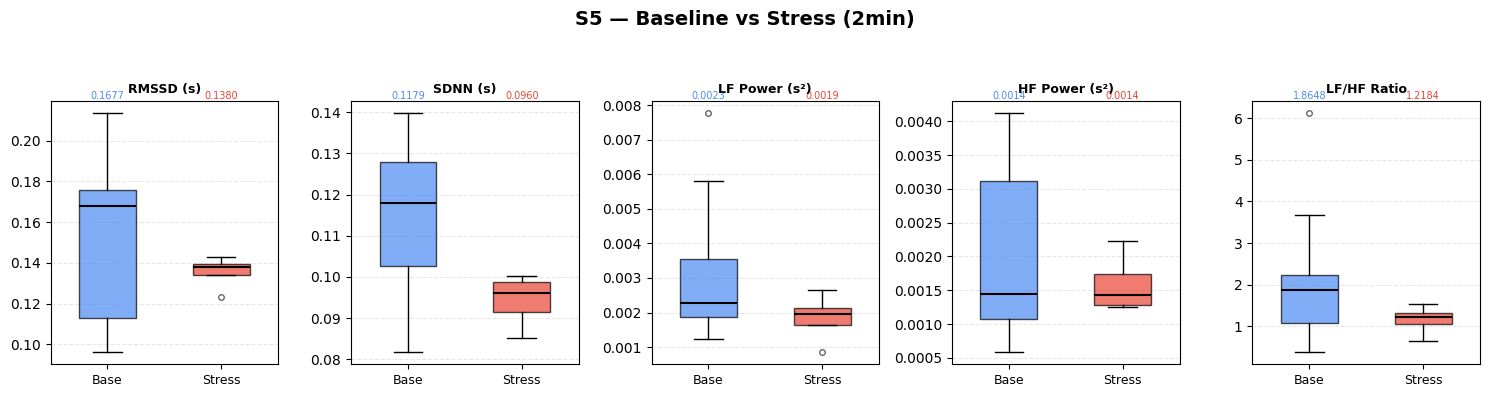

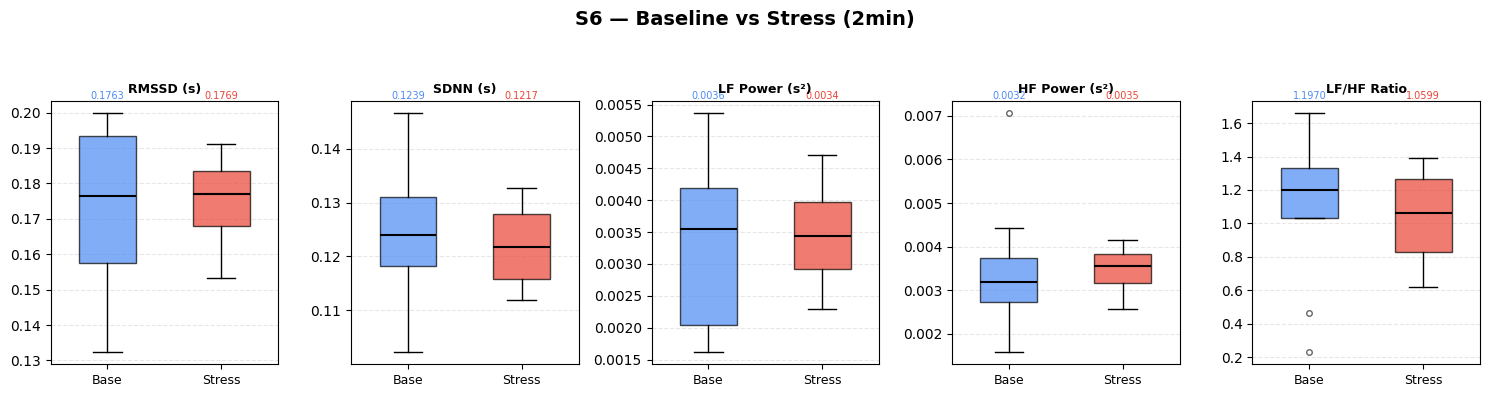

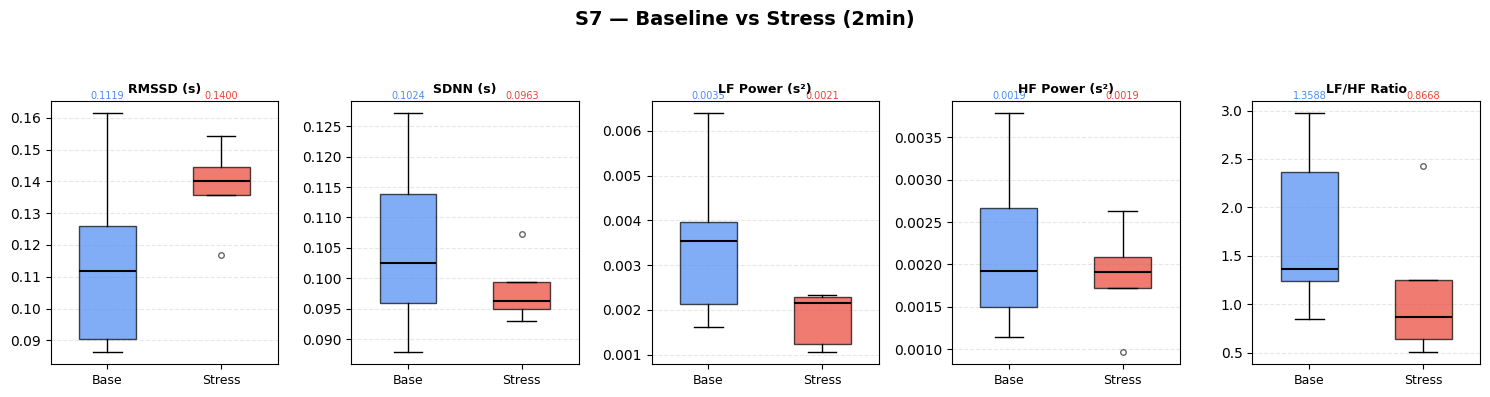

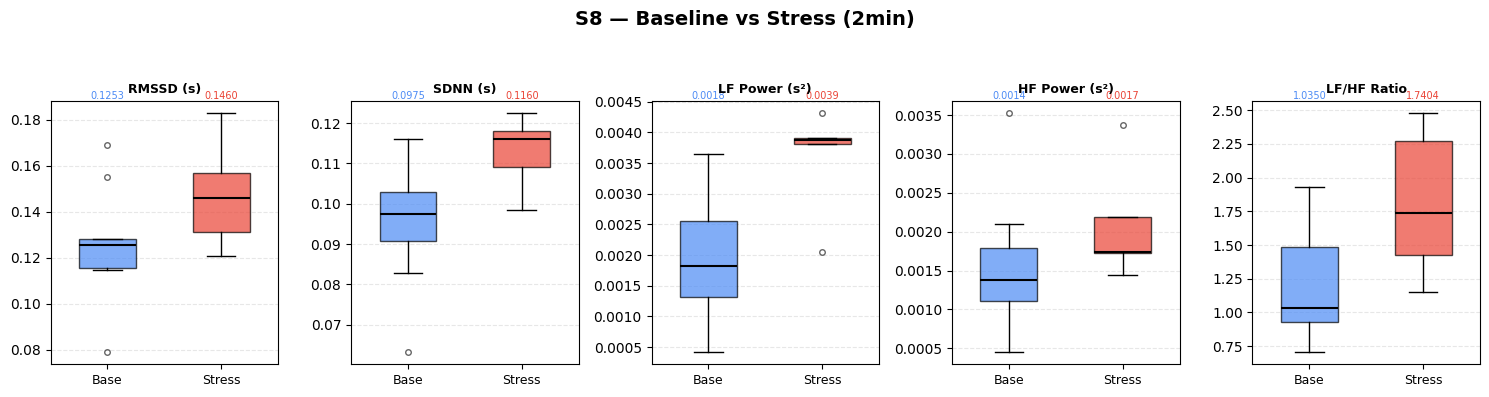

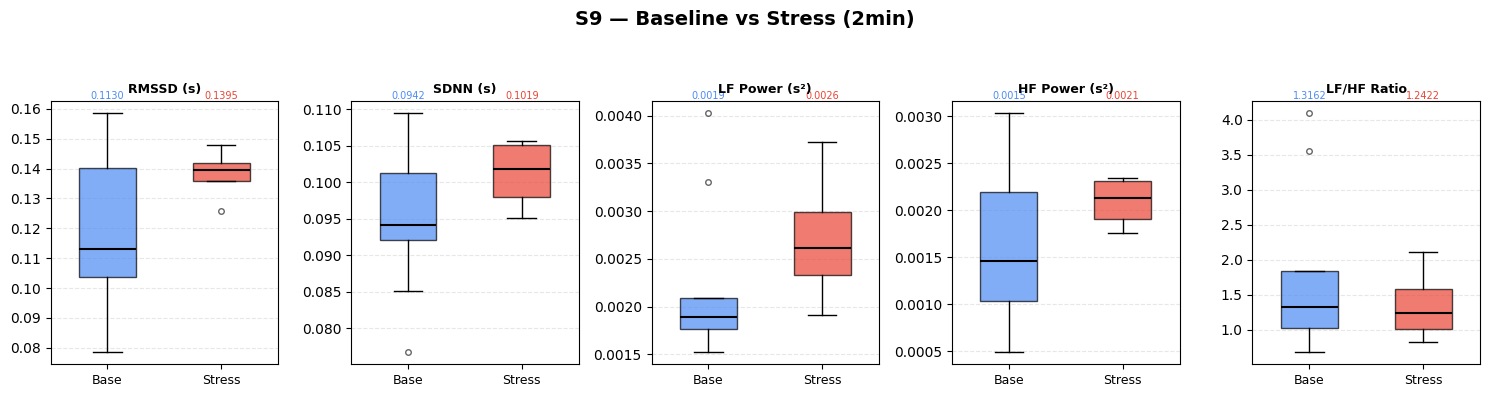

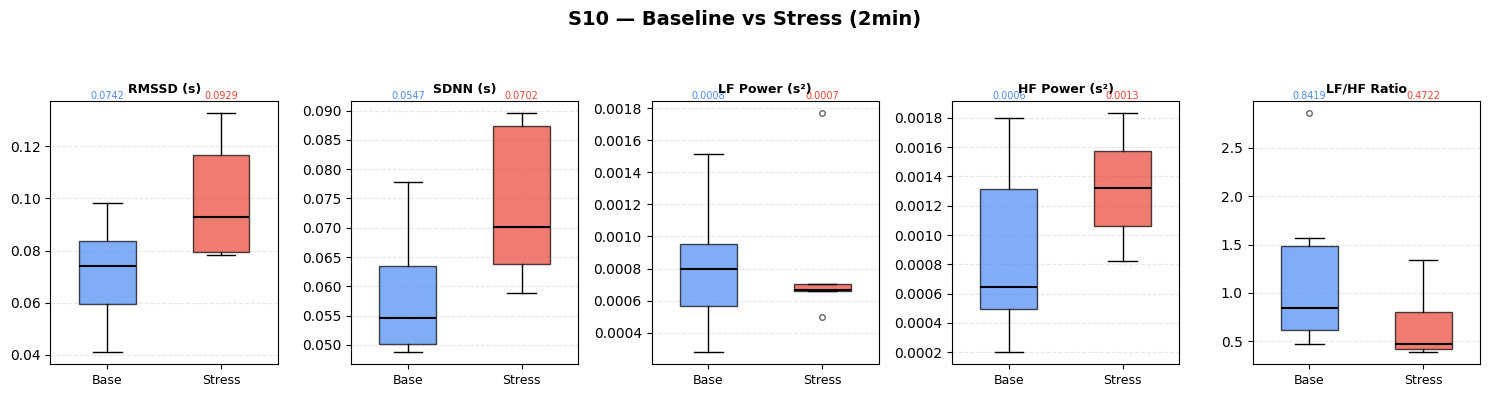

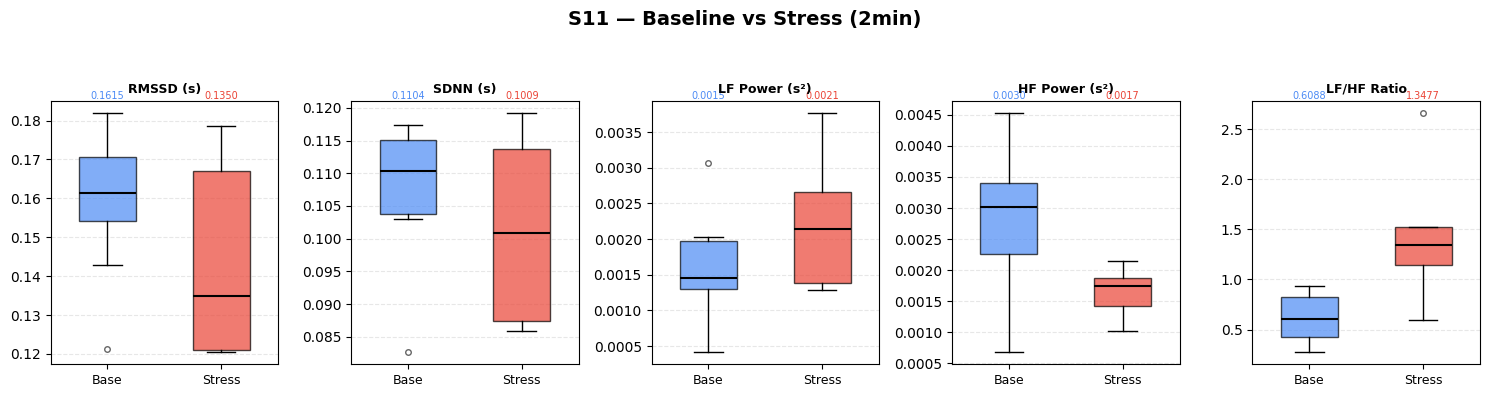

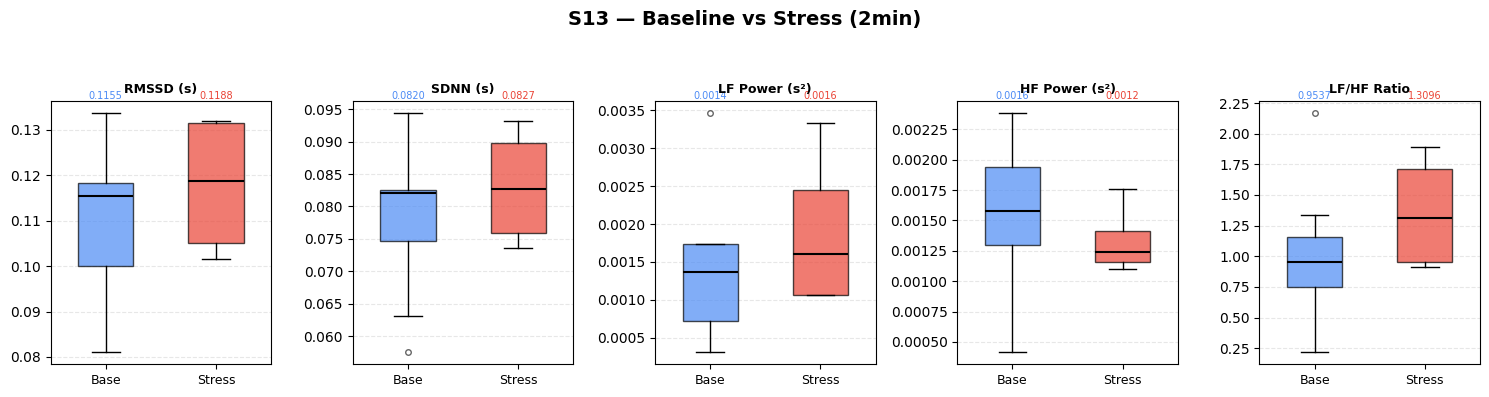

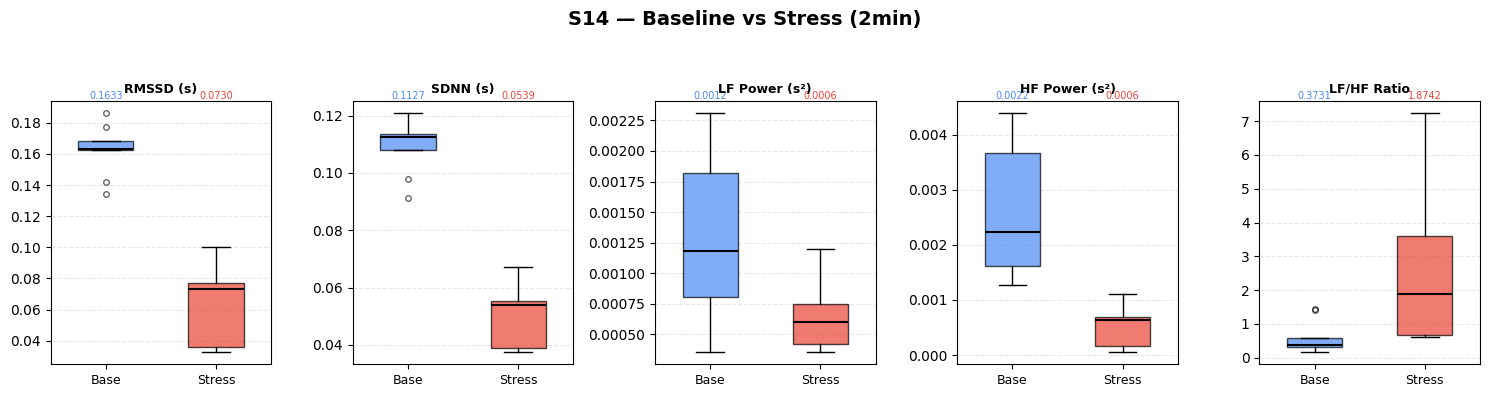

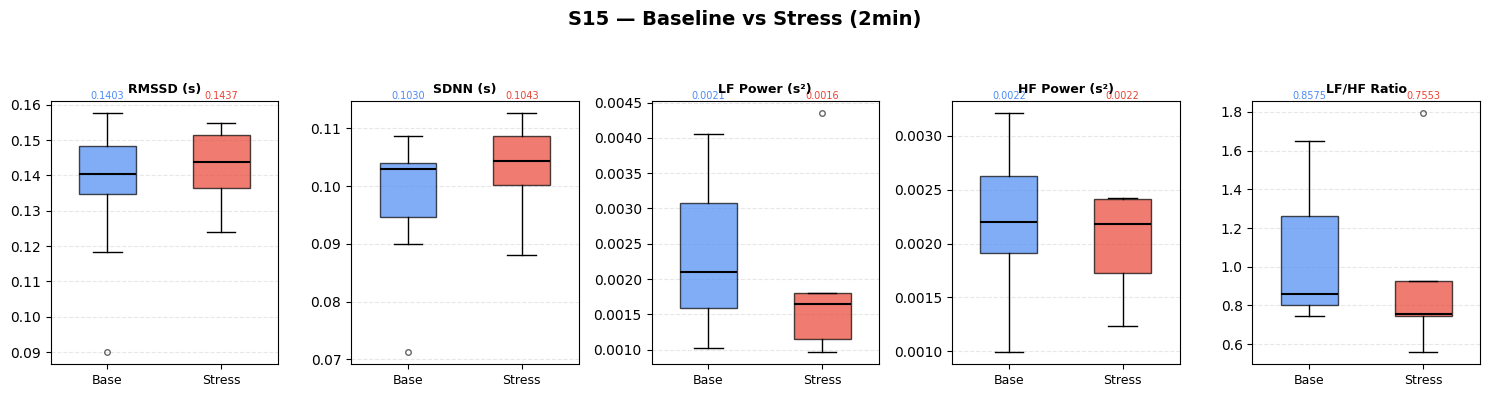

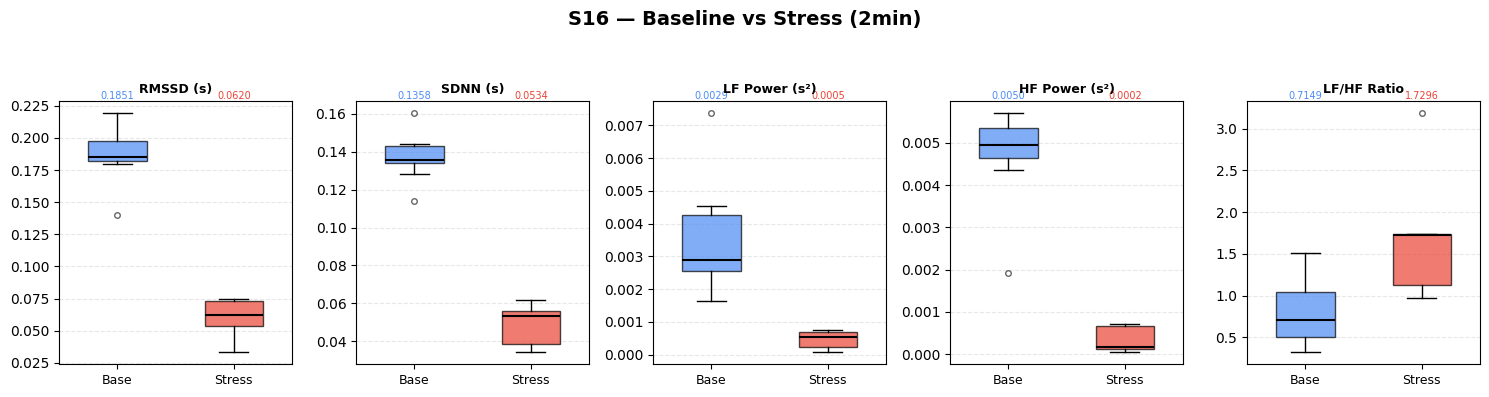

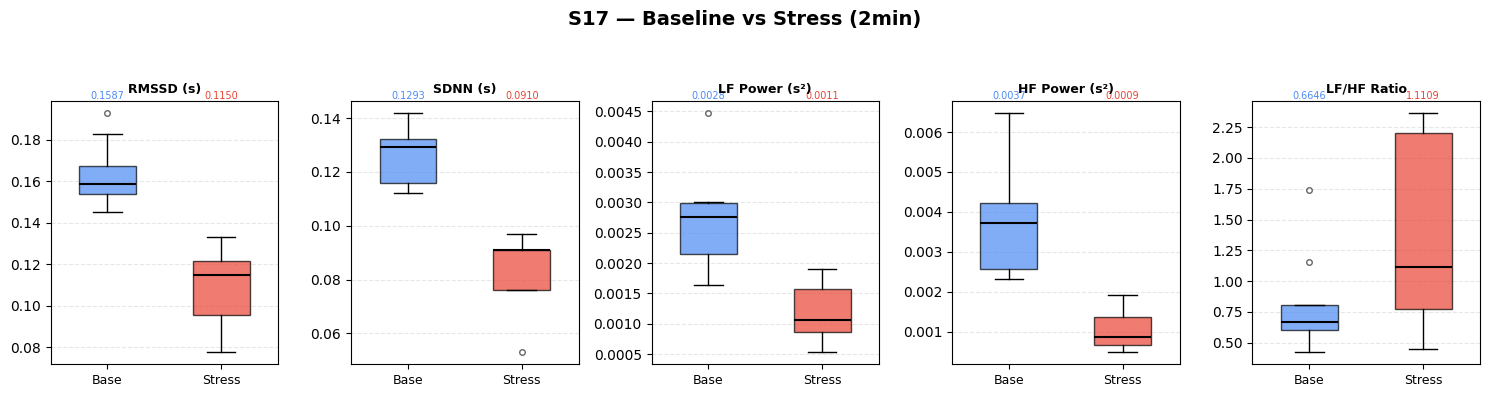

In [2]:
"""
HRV Boxplot Comparison: Baseline vs Stress per Subject
- 1min window와 2min window 각각에 대해
- 사용자별 baseline/stress HRV 지표 박스플롯 비교
- Google Colab inline 표시용 (plt.show())
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── 설정 ──────────────────────────────────────────────
HRV_METRICS = ['RMSSD', 'SDNN', 'LF', 'HF', 'LF_HF']
METRIC_LABELS = {
    'RMSSD': 'RMSSD (s)',
    'SDNN': 'SDNN (s)',
    'LF': 'LF Power (s²)',
    'HF': 'HF Power (s²)',
    'LF_HF': 'LF/HF Ratio',
}
COLORS = {'baseline': '#4C8BF5', 'stress': '#EA4335'}

# ── 데이터 로드 (Colab용 경로 수정 필요) ─────────────

df_1min = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/HRV_1min.csv')
df_2min = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/HRV_2min.csv')


def sort_subjects(subjects):
    return sorted(subjects, key=lambda x: int(x[1:]))


def plot_hrv_boxplots(df, window_label):
    """전체 사용자 overview 박스플롯"""
    df_f = df[df['status_name'].isin(['baseline', 'stress'])].copy()
    subjects = sort_subjects(df_f['subject'].unique().tolist())
    n_subjects = len(subjects)
    n_metrics = len(HRV_METRICS)

    fig, axes = plt.subplots(n_metrics, 1,
                             figsize=(max(14, n_subjects * 1.2), n_metrics * 3.2))
    fig.suptitle(f'HRV Baseline vs Stress — Per Subject ({window_label} window)',
                 fontsize=16, fontweight='bold', y=0.995)

    for row, metric in enumerate(HRV_METRICS):
        ax = axes[row]
        pos_b, pos_s, data_b, data_s = [], [], [], []

        for i, subj in enumerate(subjects):
            center = i * 3
            pos_b.append(center - 0.4)
            pos_s.append(center + 0.4)
            vb = df_f[(df_f['subject'] == subj) & (df_f['status_name'] == 'baseline')][metric].dropna().values
            vs = df_f[(df_f['subject'] == subj) & (df_f['status_name'] == 'stress')][metric].dropna().values
            data_b.append(vb if len(vb) > 0 else [np.nan])
            data_s.append(vs if len(vs) > 0 else [np.nan])

        bp_b = ax.boxplot(data_b, positions=pos_b, widths=0.6, patch_artist=True,
                          showfliers=True,
                          flierprops=dict(marker='o', markersize=3, alpha=0.5),
                          medianprops=dict(color='black', linewidth=1.5))
        bp_s = ax.boxplot(data_s, positions=pos_s, widths=0.6, patch_artist=True,
                          showfliers=True,
                          flierprops=dict(marker='o', markersize=3, alpha=0.5),
                          medianprops=dict(color='black', linewidth=1.5))

        for p in bp_b['boxes']: p.set_facecolor(COLORS['baseline']); p.set_alpha(0.7)
        for p in bp_s['boxes']: p.set_facecolor(COLORS['stress']); p.set_alpha(0.7)

        ticks = [i * 3 for i in range(n_subjects)]
        ax.set_xticks(ticks)
        ax.set_xticklabels(subjects, fontsize=9, fontweight='bold')
        ax.set_ylabel(METRIC_LABELS[metric], fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_xlim(-1.5, (n_subjects - 1) * 3 + 1.5)

        if row == 0:
            from matplotlib.patches import Patch
            ax.legend(handles=[Patch(facecolor=COLORS['baseline'], alpha=0.7, label='Baseline'),
                               Patch(facecolor=COLORS['stress'], alpha=0.7, label='Stress')],
                      loc='upper right', fontsize=9, framealpha=0.9)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def plot_per_subject_detail(df, window_label):
    """각 사용자별 개별 박스플롯"""
    df_f = df[df['status_name'].isin(['baseline', 'stress'])].copy()
    subjects = sort_subjects(df_f['subject'].unique().tolist())

    for subj in subjects:
        df_subj = df_f[df_f['subject'] == subj]
        fig, axes = plt.subplots(1, len(HRV_METRICS), figsize=(len(HRV_METRICS) * 3, 4))
        fig.suptitle(f'{subj} — Baseline vs Stress ({window_label})',
                     fontsize=14, fontweight='bold')

        for col, metric in enumerate(HRV_METRICS):
            ax = axes[col]
            vb = df_subj[df_subj['status_name'] == 'baseline'][metric].dropna().values
            vs = df_subj[df_subj['status_name'] == 'stress'][metric].dropna().values

            bp = ax.boxplot([vb, vs], positions=[1, 2], widths=0.5, patch_artist=True,
                            showfliers=True,
                            flierprops=dict(marker='o', markersize=4, alpha=0.6),
                            medianprops=dict(color='black', linewidth=1.5))
            bp['boxes'][0].set_facecolor(COLORS['baseline']); bp['boxes'][0].set_alpha(0.7)
            bp['boxes'][1].set_facecolor(COLORS['stress']); bp['boxes'][1].set_alpha(0.7)

            ax.set_xticks([1, 2])
            ax.set_xticklabels(['Base', 'Stress'], fontsize=9)
            ax.set_title(METRIC_LABELS[metric], fontsize=9, fontweight='bold')
            ax.grid(axis='y', alpha=0.3, linestyle='--')

            if len(vb) > 0:
                ax.text(1, ax.get_ylim()[1], f'{np.median(vb):.4f}',
                        ha='center', va='bottom', fontsize=7, color=COLORS['baseline'])
            if len(vs) > 0:
                ax.text(2, ax.get_ylim()[1], f'{np.median(vs):.4f}',
                        ha='center', va='bottom', fontsize=7, color=COLORS['stress'])

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()


# ── 실행 ─────────────────────────────────────────────
print("=" * 60)
print("📊 [1min window] Overview")
print("=" * 60)
plot_hrv_boxplots(df_1min, '1min')

print("\n" + "=" * 60)
print("📊 [2min window] Overview")
print("=" * 60)
plot_hrv_boxplots(df_2min, '2min')

print("\n" + "=" * 60)
print("📊 [1min window] Per-Subject Detail")
print("=" * 60)
plot_per_subject_detail(df_1min, '1min')

print("\n" + "=" * 60)
print("📊 [2min window] Per-Subject Detail")
print("=" * 60)
plot_per_subject_detail(df_2min, '2min')